In [1]:
# Import Libraries
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from IPython.display import display
from google.colab import drive
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

In [2]:
# Enable and Confirm GPU Support
# XGboost must run a "dummy test" to confirm
try:
    xgb.train(
        {"device": "cuda"},
        xgb.DMatrix([[0]], label=[0]),
        num_boost_round=1
    )
    DEVICE = "cuda"
    print("GPU confirmed. XGBoost is using CUDA.")

except Exception as gpu_error:
    try:
        xgb.train(
            {"device": "cpu"},
            xgb.DMatrix([[0]], label=[0]),
            num_boost_round=1
        )
        DEVICE = "cpu"
        print(
            f"GPU support unavailable. [Reason: {gpu_error}]\n"
            f"Model has successfully defaulted to CPU usage instead."
        )

    except Exception as cpu_error:
        DEVICE = None
        print(
            f"GPU and CPU usage are both unavailable.\n"
            f"  GPU Reason: {gpu_error}\n"
            f"  CPU Reason: {cpu_error}\n\n"
            f"Troubleshooting suggestions:\n"
            f"  1. Verify XGBoost is installed correctly  : pip install xgboost\n"
            f"  2. Verify your CUDA drivers are up to date : https://developer.nvidia.com/cuda-downloads\n"
            f"  3. Confirm your Python environment is not corrupted\n"
            f"  4. Try reinstalling XGBoost                : pip install --force-reinstall xgboost"
        )

GPU confirmed. XGBoost is using CUDA.


In [3]:
# Define file path & Load TRAIN and VALIDATE Datasets
drive.mount('/content/drive', force_remount=True)
df = pd.read_csv('/content/drive/MyDrive/xg-ids/3class/datasets/3class_TRAIN.txt')
df_val = pd.read_csv('/content/drive/MyDrive/xg-ids/3class/datasets/3class_VALIDATE.txt')

Mounted at /content/drive


In [4]:
# XGBOOST CONFIGURATIONS
config = {

    #GLOBAL & GENERAL CONFIGURATIONS
    "verbosity"            : 1,                # 0 (silent), 1 (warning), 2 (info), 3 (debug)
    # "use_rmm"               : False,            # DEFAULT: FALSE -- RMM XGBoost not required or installed (Only relevant for production pipelines)
    # "use_cuda_async_pool"   : False,            # DEFAULT: FALSE -- Uses CUDA's built-in memory pool for faster GPU memory allocation.
    # "nthread" - Only Applicable for overriding multi-threading CPU behavior. [Default is to auto-detect and use all cores]
    "booster"              : "gbtree",         # DEFAULT: gbtree --  Options: "gbtree" (Standard Gradient Boosting), "gblinear" (Linear Models), "dart" (Dropout Trees)
    "device"               : DEVICE,           # Options: "cuda", "cpu" - Specified in cell 2
    "validate_parameters"  : True,          # Use with Python. XGBoost validates input parameters and warns if any are unused or unrecognized.
    "disable_default_eval_metric" : False,    # XGBoost supports variety of "eval_metric" options with defaults and customizability.

    # TREE BOOSTER PARAMETERS
    "eta"                  : 0.6,              # DEFAULT: 0.3 - Alias for "learning_rate". Controls step size shrinkage to prevent overfitting.
    "gamma"                : 0,                # DEFAULT: 0 - Minimum loss reduction required to make a split. Higher values = more conservative models.
    "max_depth"            : 6,                # DEFAULT: 6 - Maximum depth of a tree. Increasing may capture more complex patterns BUT may overfit.
    "min_child_weight"     : 1,                # DEFAULT: 1 - [Options: 0,∞] Minimum sum of instance weight (hessian) needed in a child. Higher values prevent overfitting.
                                               # Relevant for U2R and R2L (Low # might cause overfitting)
    "max_delta_step"       : 0,                # DEFAULT: 0 - Maximum delta step allowed. 0 = no constraints. May help with logistic regressionin imbalanced datasets.
    "subsample"           : 0.5,                # DEFAULT: 1 - [Range: 0,1]Randomly subsample dataset prior to growing tree. May prevent overfitting. Occurs once per boosting iteration.
    "sampling_method"      : "uniform",        # DEFAULT: uniform - Options: "uniform" (Random sampling), "gradient_based" (Gradient-based sampling)
    # ALL parameters in the "column" sampling family remain at their default value 1 to disable random column sampling.
    # This is to ensure no uncontrolled variables are introduced in the feature selection process.
    "lambda"               : 1,                # DEFAULT: 1 - [Options: 0,∞] (Alias: reg_lambda) L2 regularization term on weights. Increase = more conservative models.
    "alpha"                : 0,                # DEFAULT: 0 - [Options: 0,∞] (Alias: reg_alpha) L1 regularization term on weights. Increase = more conservative models.
    "tree_method"         : "hist",            # DEFAULT: auto - Options: "auto" (same as "hist"), "exact" (Exact greedy algorithm), "approx" (Approximate algorithm using quantile sketching), "hist" (Histogram-based algorithm)
    # "scale_pos_weight"  : 1,                   # DEFAULT: 1 - Not applicable for multiclass classifcation. (Only relevant for binary classification)
    # "updater"         #Extremely advanced parameter set automatically. Not recommended for manual tuning. See documentation for details.
    # "refresh_leaf"    # Related to "updater" parameter. Not recommended for manual tuning. See documentation for details.
    "process_type"        : "default",         # DEFAULT: default - Options: "default" (Standard training), "update" (Continue training from existing model)
    # "grow_policy"        : "depthwise",       # DEFAULT: depthwise - Options: "depthwise" (Split at nodes with highest depth first. More controlled, less overfitting)), "lossguide" (Split at nodes with highest loss reduction first, prone to overfitting)
    # "max_leaves"         : 0,                # DEFAULT: 0 - Maximum number of leaves in a tree. Only relevant when grow_policy=lossguide. Higher values may lead to overfitting.
    # "max_bin"           : 256,              # DEFAULT: 256 - Number of bins for histogram-based algorithms. Higher values may lead to better accuracy (esp for U2R & R2L) but slower training.
    # "num_parallel_tree" : 1,                # DEFAULT: 1 - Number of trees to grow per round (Supports Boosted Random Forest). Keep at 1 to prevent affecting feature importance scores.
    # "monotonic_constraints" : None,             # DEFAULT: None - Ignore for Feature Selection purposes.
    # "interaction_constraints" : None,            # DEFAULT: None - Ignore for Feature Selection purposes.
    # "max_cached_hist_node" : 65536,            # DEFAULT: 65536 - Maximum number of nodes to cache for histogram-based algorithms. Increase = speed up training + consume more memory.
    # "max_cat_to_onehot" Ignore - we are explicitely not using One-Hot Encoding
    # Skip all parameters related to Dart Booster
    # Skip all parameters related to Linear Booster
    "objective"            : "multi:softprob", # Many other options (see documentation), but "multi:softmax" is likely the most promising alternative.
    # "base_score" -- Automatically estimated by XGBoost for multi:softprob — no manual override needed
    "eval_metric" : ["mlogloss", "merror"], # Defaults to "mlogloss" for multi:softprob, but can be overridden with other options. See documentation.
    "seed" : 0, # RNG to ensure reproducibility of results across different runs/environments.

    # Parameters related to Tweedie Regression, Pseudo-Huber, Quantile Loss, AFT Survival Loss skipped - irrelevant for multiclass classification.

    # PARAMETERS NOT LISTED IN DOCUMENTATION BUT RELEVANT FOR FEATURE SELECTION
    "enable_categorical" : True, # Avoids using One-Hot Encoding and allows XGBoost to natively handle categorical features.
    "num_class"            : 3,  # Required for multiclass classification with "multi:softprob" objective. Specifies number of classes in the dataset.
    "n_estimators"         : 500,              # DEFAULT: 100 - Number of boosting rounds (trees).
    "early_stopping_rounds": 30,        # DEFAULT: None -- Early stopping if no imporvement (eval metric) for specified rounds.
    # Prototyping
    "prototyping"          : False,
    "prototyping_frac"     : 0.2,              # fraction of data to use when prototyping
    "prototyping_stratified": True,            # ensure all classes are represented
}

In [5]:
# TRAIN & VALIDATE Dataset: Encode datasets + separate Features and Targets
# Cast categorical feature columns to category dtype for XGBoost native handling
categorical_cols = ['protocol_type', 'service', 'flag']
for col in categorical_cols:
    df[col]     = df[col].astype('category')
    df_val[col] = df_val[col].astype('category')

# Encode target class labels to integers (required by XGBoost)
le = LabelEncoder()
df['class']     = le.fit_transform(df['class'])
df_val['class'] = le.transform(df_val['class'])

# Print class encoding map
class_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class encoding map:")
for cls, idx in class_map.items():
    print(f"  {cls} → {idx}")

# Separate features and target
X_train = df.drop(columns=['class'])
y_train = df['class']

X_val   = df_val.drop(columns=['class'])
y_val   = df_val['class']

Class encoding map:
  DoS → 0
  Normal → 1
  Probe → 2


In [6]:
# Prototyping Configurations
if config["prototyping"]:
    X_train, _, y_train, _ = train_test_split(
        X_train, y_train,
        train_size=config["prototyping_frac"],
        stratify=y_train if config["prototyping_stratified"] else None,
        random_state=config["seed"]
    )
    X_val, _, y_val, _ = train_test_split(
        X_val, y_val,
        train_size=config["prototyping_frac"],
        stratify=y_val if config["prototyping_stratified"] else None,
        random_state=config["seed"]
    )
    print(f"Prototyping mode: using {len(X_train)} train instances and {len(X_val)} val instances ({config['prototyping_frac']*100:.0f}% of each dataset)")
else:
    print(f"Full training mode: using {len(X_train)} train instances and {len(X_val)} val instances")

Full training mode: using 38491 train instances and 12493 val instances


In [7]:
model = xgb.XGBClassifier(
    verbosity          = config["verbosity"],
    booster            = config["booster"],
    device             = config["device"],
    validate_parameters= config["validate_parameters"],
    eta                = config["eta"],
    gamma              = config["gamma"],
    max_depth          = config["max_depth"],
    min_child_weight   = config["min_child_weight"],
    max_delta_step     = config["max_delta_step"],
    subsample          = config["subsample"],
    sampling_method    = config["sampling_method"],
    reg_lambda         = config["lambda"],
    reg_alpha          = config["alpha"],
    tree_method        = config["tree_method"],
    process_type       = config["process_type"],
    objective          = config["objective"],
    eval_metric        = config["eval_metric"],
    seed               = config["seed"],
    enable_categorical = config["enable_categorical"],
    num_class          = config["num_class"],
    n_estimators       = config["n_estimators"],
    early_stopping_rounds = config["early_stopping_rounds"],
)

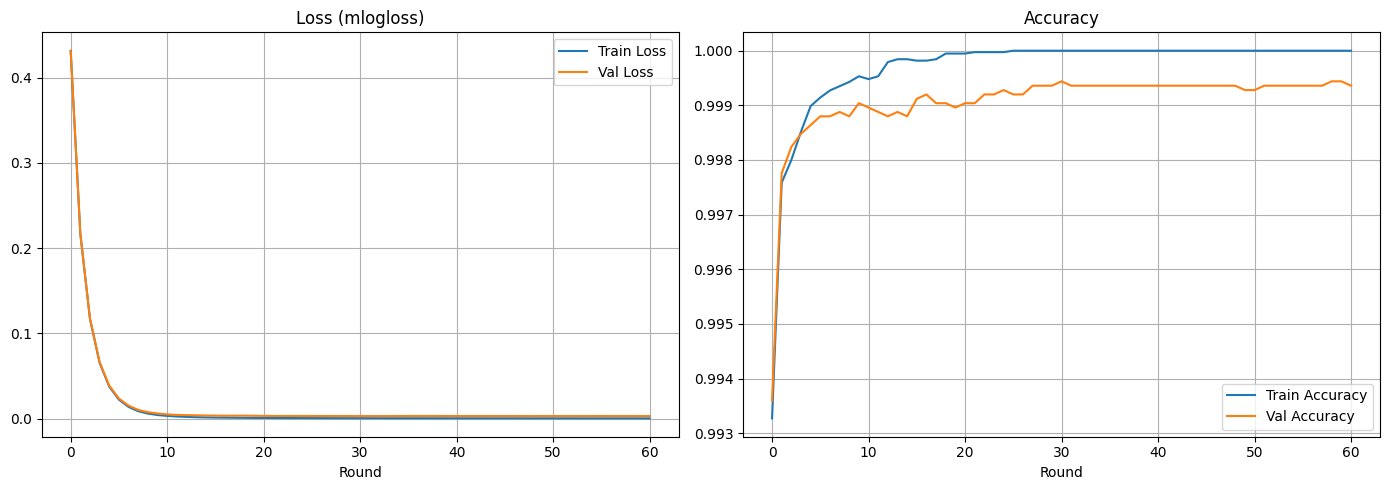

In [8]:
evals_result = {}

model.fit(
    X_train, y_train.to_numpy(),
    sample_weight=compute_sample_weight('balanced', y_train),
    eval_set=[(X_train, y_train.to_numpy()), (X_val, y_val.to_numpy())],
    verbose=False
)

# Plot after training
evals_result = model.evals_result()
train_loss = evals_result["validation_0"]["mlogloss"]
val_loss   = evals_result["validation_1"]["mlogloss"]
train_acc  = [1 - e for e in evals_result["validation_0"]["merror"]]
val_acc    = [1 - e for e in evals_result["validation_1"]["merror"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_loss, label="Train Loss")
ax1.plot(val_loss,   label="Val Loss")
ax1.set_title("Loss (mlogloss)")
ax1.set_xlabel("Round")
ax1.legend()
ax1.grid(True)

ax2.plot(train_acc, label="Train Accuracy")
ax2.plot(val_acc,   label="Val Accuracy")
ax2.set_title("Accuracy")
ax2.set_xlabel("Round")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

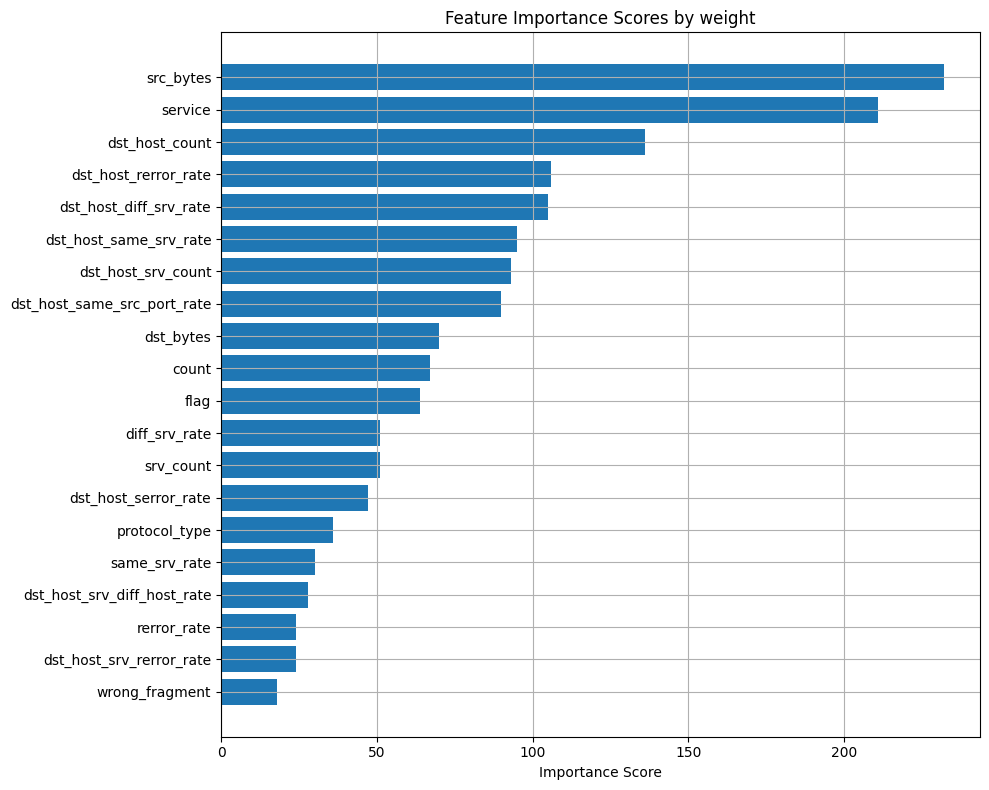


 Feature Importance Scores (weight):
                    feature  importance
                  src_bytes       232.0
                    service       211.0
             dst_host_count       136.0
       dst_host_rerror_rate       106.0
     dst_host_diff_srv_rate       105.0
     dst_host_same_srv_rate        95.0
         dst_host_srv_count        93.0
dst_host_same_src_port_rate        90.0
                  dst_bytes        70.0
                      count        67.0
                       flag        64.0
              diff_srv_rate        51.0
                  srv_count        51.0
       dst_host_serror_rate        47.0
              protocol_type        36.0
              same_srv_rate        30.0
dst_host_srv_diff_host_rate        28.0
                rerror_rate        24.0
   dst_host_srv_rerror_rate        24.0
             wrong_fragment        18.0
                   duration        17.0
                  logged_in        15.0
            num_compromised         9.0
  

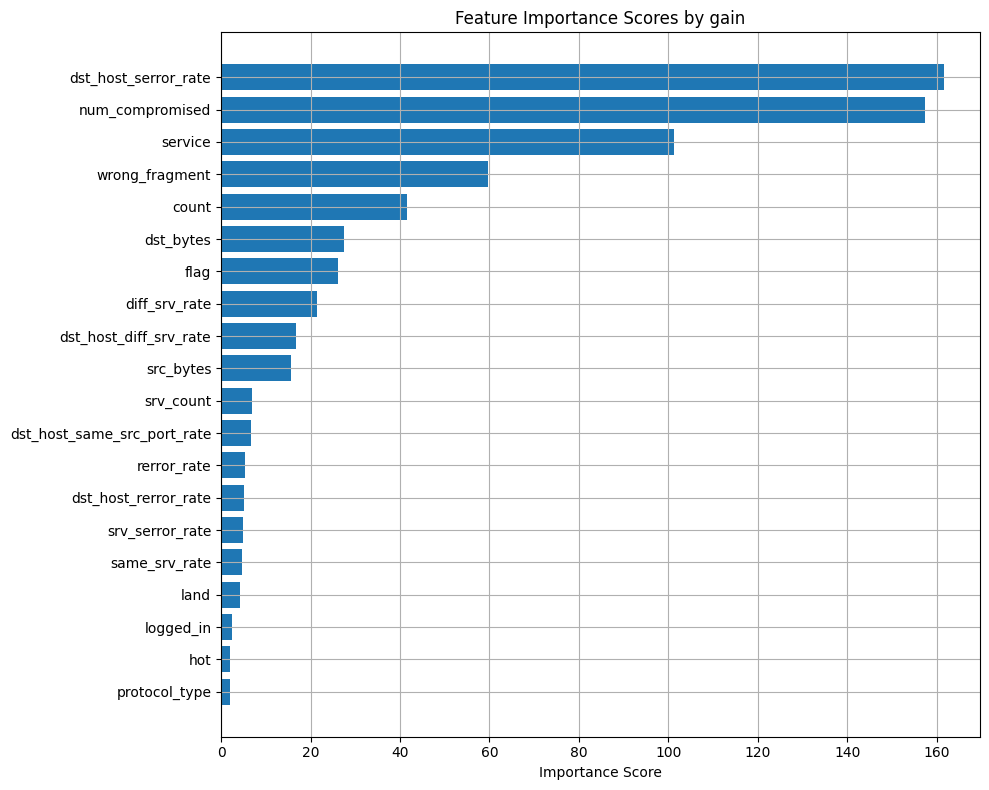


 Feature Importance Scores (gain):
                    feature  importance
       dst_host_serror_rate  161.606888
            num_compromised  157.400238
                    service  101.331711
             wrong_fragment   59.630013
                      count   41.528023
                  dst_bytes   27.377150
                       flag   26.161285
              diff_srv_rate   21.517399
     dst_host_diff_srv_rate   16.637997
                  src_bytes   15.667991
                  srv_count    6.843061
dst_host_same_src_port_rate    6.727884
                rerror_rate    5.393355
       dst_host_rerror_rate    5.163719
            srv_serror_rate    4.889147
              same_srv_rate    4.699030
                       land    4.169408
                  logged_in    2.407638
                        hot    2.068787
              protocol_type    2.022610
             dst_host_count    1.737903
     dst_host_same_srv_rate    1.165563
                   duration    1.037879
    

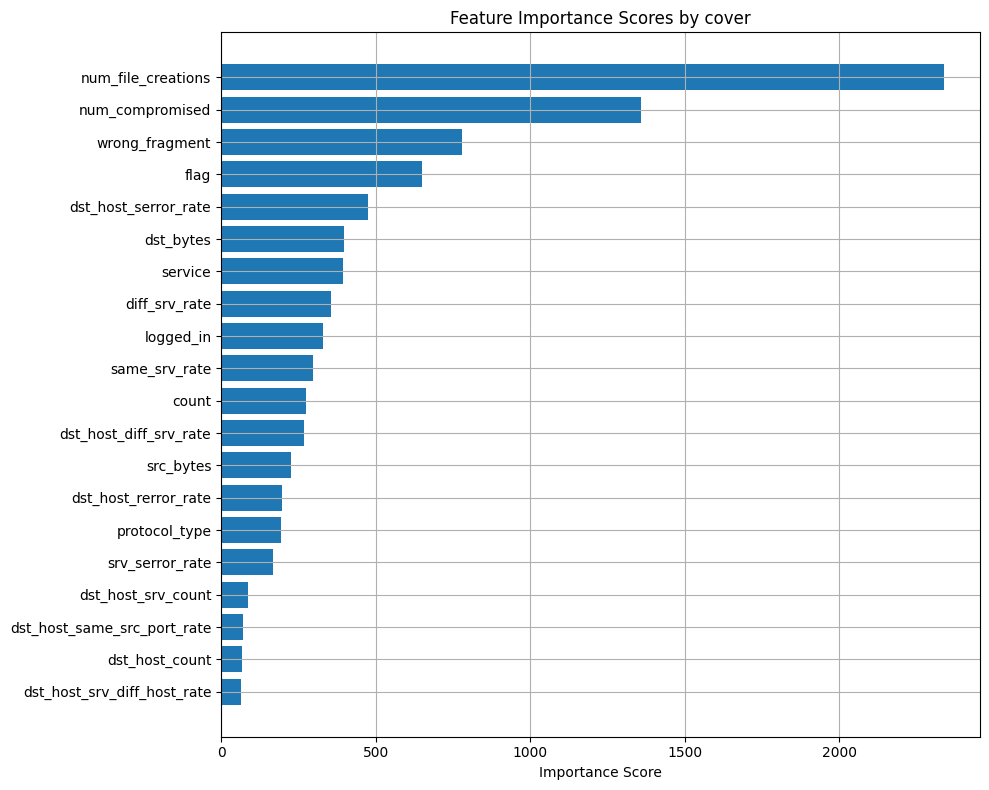


 Feature Importance Scores (cover):
                    feature  importance
         num_file_creations 2338.444092
            num_compromised 1356.954346
             wrong_fragment  779.544678
                       flag  649.080383
       dst_host_serror_rate  474.773682
                  dst_bytes  397.656738
                    service  393.829498
              diff_srv_rate  356.668915
                  logged_in  328.976471
              same_srv_rate  298.107361
                      count  276.246704
     dst_host_diff_srv_rate  267.913910
                  src_bytes  224.937180
       dst_host_rerror_rate  198.030121
              protocol_type  193.934982
            srv_serror_rate  168.780289
         dst_host_srv_count   88.364899
dst_host_same_src_port_rate   71.934654
             dst_host_count   66.093994
dst_host_srv_diff_host_rate   64.238419
         srv_diff_host_rate   62.182587
                        hot   56.828407
                  srv_count   49.105530
   

In [9]:
# Feature Importance
importance_types = ['weight', 'gain', 'cover']

for imp_type in importance_types:
    scores = model.get_booster().get_score(importance_type=imp_type)
    importance_df = pd.DataFrame({
        'feature': X_train.columns.tolist(),
        'importance': [scores.get(f, 0.0) for f in X_train.columns]
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    top = importance_df.head(20)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top['feature'][::-1], top['importance'][::-1])
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Feature Importance Scores by {imp_type}')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\n Feature Importance Scores ({imp_type}):")
    print(importance_df.head(43).to_string(index=False))

In [10]:
# Load in Test Dataset, Encode it, and separate features and target
# Load test set
df_test = pd.read_csv('/content/drive/MyDrive/xg-ids/3class/datasets/3class_test.txt')

# Cast categorical feature columns to category dtype
for col in categorical_cols:
    df_test[col] = df_test[col].astype('category')

# Encode target using the same LabelEncoder fitted on train set
df_test['class'] = le.transform(df_test['class'])

# Separate features and target
X_test = df_test.drop(columns=['class'])
y_test = df_test['class']

print(f"Test set loaded: {len(df_test)} instances")

Test set loaded: 19590 instances


Accuracy          : 0.9075
F1 (macro)        : 0.8870
F1 (weighted)     : 0.9070
Precision (weighted): 0.9105
Recall (weighted) : 0.9075

Per-class F1:
  DoS: 0.9022
  Normal: 0.9302
  Probe: 0.8286

Classification Report:
              precision    recall  f1-score   support

         DoS       0.96      0.85      0.90      7458
      Normal       0.89      0.97      0.93      9711
       Probe       0.82      0.83      0.83      2421

    accuracy                           0.91     19590
   macro avg       0.89      0.88      0.89     19590
weighted avg       0.91      0.91      0.91     19590



/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [23:01:31] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


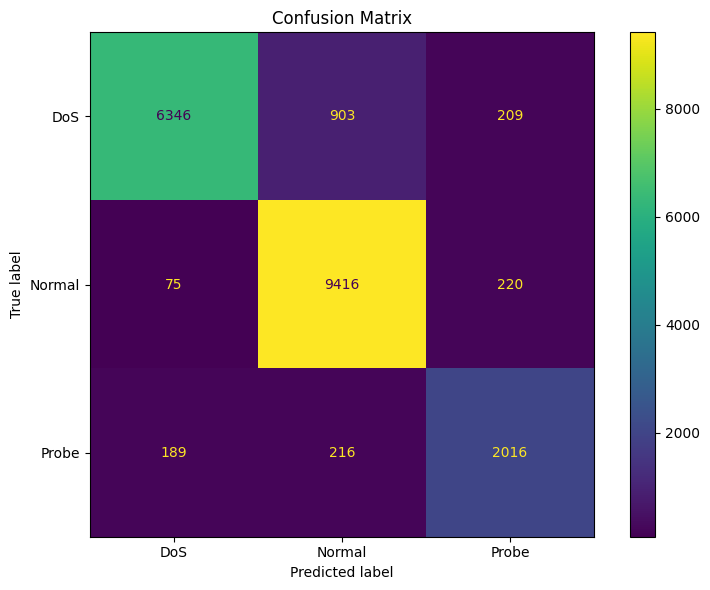

In [11]:

y_pred = model.predict(X_test)


accuracy  = accuracy_score(y_test, y_pred)
f1_macro  = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')

print(f"Accuracy          : {accuracy:.4f}")
print(f"F1 (macro)        : {f1_macro:.4f}")
print(f"F1 (weighted)     : {f1_weighted:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted) : {recall:.4f}")

# F1-Score
f1_per_class = f1_score(y_test, y_pred, average=None)
print(f"\nPer-class F1:")
for cls, score in zip(le.classes_, f1_per_class):
    print(f"  {cls}: {score:.4f}")

# Classification
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()